In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install onnxruntime opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.8 MB/s eta 0:00:00


In [ ]:
import os
from glob import glob

input_real = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final/face_real"
input_fake = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final/face_fake"

real_images = glob(os.path.join(input_real, "*.jpg"))
fake_images = glob(os.path.join(input_fake, "*.jpg"))

print("Real images:", len(real_images))
print("Fake images:", len(fake_images))
print("Total:", len(real_images) + len(fake_images))

Real images: 5792
Fake images: 9356
Total: 15148


# Kiểm Tra Định Dạng

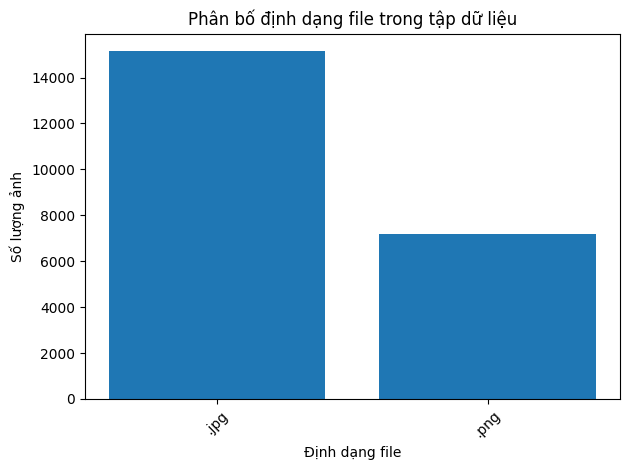

In [ ]:
import os
from glob import glob
import matplotlib.pyplot as plt
from collections import Counter
# Lấy tất cả file
all_files = glob(os.path.join(input_real, "*")) + glob(os.path.join(input_fake, "*"))

# Lấy định dạng file
exts = [os.path.splitext(f)[1].lower() for f in all_files]

# Đếm số lượng
ext_count = Counter(exts)

# Vẽ biểu đồ
plt.figure()
plt.bar(ext_count.keys(), ext_count.values())

plt.xlabel("Định dạng file")
plt.ylabel("Số lượng ảnh")
plt.title("Phân bố định dạng file trong tập dữ liệu")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Convert về chung định dạng " jpg "

In [ ]:
import os
import cv2
from glob import glob
from tqdm import tqdm

real_path = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final/face_real"
fake_path = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final/face_fake"

save_real = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_real"
save_fake = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_fake"

os.makedirs(save_real, exist_ok=True)
os.makedirs(save_fake, exist_ok=True)


def convert_folder(input_folder, save_folder):

    images = glob(input_folder + "/*")

    count = 0

    for img_path in tqdm(images):

        img = cv2.imread(img_path)
        if img is None:
            continue

        save_path = os.path.join(
            save_folder,
            f"{count:06d}.jpg"
        )

        cv2.imwrite(save_path, img)
        count += 1


# convert
convert_folder(real_path, save_real)
convert_folder(fake_path, save_fake)

print("DONE")

100%|██████████| 15427/15427 [18:51<00:00, 13.63it/s]


DONE


Tổng số ảnh JPG: 22328


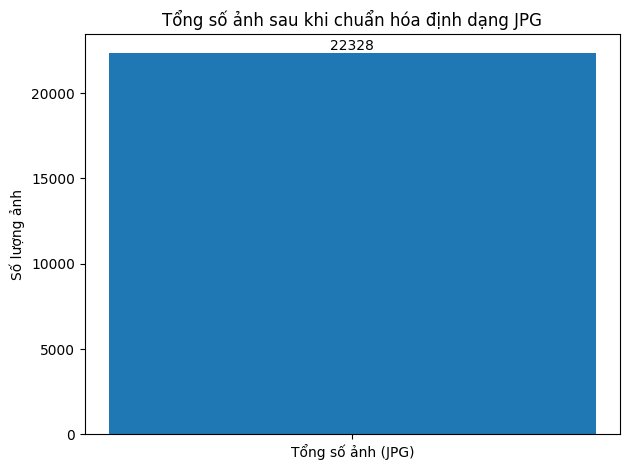

In [ ]:
save_real = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_real"
save_fake = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_fake"

# Lấy toàn bộ ảnh
all_images = glob(os.path.join(save_real, "*.jpg")) + \
             glob(os.path.join(save_fake, "*.jpg"))

total = len(all_images)

print("Tổng số ảnh JPG:", total)

# ===== VẼ BIỂU ĐỒ =====
plt.figure()
bars = plt.bar(["Tổng số ảnh (JPG)"], [total])

# Hiển thị số
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.ylabel("Số lượng ảnh")
plt.title("Tổng số ảnh sau khi chuẩn hóa định dạng JPG")

plt.tight_layout()
plt.show()

# Tổng số bản ghi

In [ ]:
import os
from glob import glob

input_real = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_real"
input_fake = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_fake"

real_images = glob(os.path.join(input_real, "*.jpg"))
fake_images = glob(os.path.join(input_fake, "*.jpg"))

print("Real images:", len(real_images))
print("Fake images:", len(fake_images))
print("Total:", len(real_images) + len(fake_images))

Real images: 6901
Fake images: 15427
Total: 22328


# SRCDF

In [ ]:
import os
import cv2
import numpy as np
import onnxruntime
from glob import glob
from tqdm import tqdm


# ================================
# NMS
# ================================
def nms(boxes, iou_threshold=0.4):
    if len(boxes) == 0:
        return []

    boxes = boxes.astype(np.float32)

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]

    areas = (x2 - x1) * (y2 - y1)
    order = areas.argsort()[::-1]

    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)

        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return boxes[keep]


# ================================
# SCRFD utils
# ================================
def distance2bbox(points, distance):
    x1 = points[:, 0] - distance[:, 0]
    y1 = points[:, 1] - distance[:, 1]
    x2 = points[:, 0] + distance[:, 2]
    y2 = points[:, 1] + distance[:, 3]
    return np.stack([x1, y1, x2, y2], axis=-1)


# ================================
# SCRFD class
# ================================
class SCRFD:
    def __init__(self, model_path, input_size=(640,640), conf_thres=0.3):

        self.input_size = input_size
        self.conf_thres = conf_thres

        self.fmc = 3
        self._feat_stride_fpn = [8,16,32]

        self.mean = 127.5
        self.std = 128.0

        self.session = onnxruntime.InferenceSession(
            model_path,
            providers=['CPUExecutionProvider']
        )

        self.input_name = self.session.get_inputs()[0].name
        self.output_names = [o.name for o in self.session.get_outputs()]

    def forward(self, image):

        blob = cv2.dnn.blobFromImage(
            image,
            1.0/self.std,
            self.input_size,
            (self.mean, self.mean, self.mean),
            swapRB=True
        )

        outputs = self.session.run(self.output_names, {self.input_name: blob})

        scores_list = []
        bboxes_list = []

        input_height = blob.shape[2]
        input_width = blob.shape[3]

        for idx, stride in enumerate([8,16,32]):

            scores = outputs[idx]
            bbox_preds = outputs[idx + 3] * stride

            height = input_height // stride
            width = input_width // stride

            anchor_centers = np.stack(
                np.mgrid[:height, :width][::-1], axis=-1
            ).astype(np.float32)

            anchor_centers = (anchor_centers * stride).reshape((-1,2))
            anchor_centers = np.stack([anchor_centers]*2, axis=1).reshape((-1,2))

            pos_inds = np.where(scores >= self.conf_thres)[0]

            bboxes = distance2bbox(anchor_centers, bbox_preds)

            scores_list.append(scores[pos_inds])
            bboxes_list.append(bboxes[pos_inds])

        return scores_list, bboxes_list

    def detect(self, image):

        h, w = image.shape[:2]

        resized = cv2.resize(image, self.input_size)

        scale_x = w / self.input_size[0]
        scale_y = h / self.input_size[1]

        scores_list, bboxes_list = self.forward(resized)

        if len(scores_list) == 0:
            return []

        scores = np.vstack(scores_list)
        bboxes = np.vstack(bboxes_list)

        inds = np.where(scores > self.conf_thres)[0]
        bboxes = bboxes[inds]

        # scale về ảnh gốc
        bboxes[:,0] *= scale_x
        bboxes[:,1] *= scale_y
        bboxes[:,2] *= scale_x
        bboxes[:,3] *= scale_y

        # ===== NMS =====
        bboxes = nms(bboxes, 0.4)

        return bboxes


# ================================
# Load model
# ================================
model_path = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/SCRDF/det_500m.onnx"
detector = SCRFD(model_path)


# ================================
# paths
# ================================
input_real = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_real"
input_fake = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_fake"

save_real = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_crop/face_real_crop"
save_fake = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_crop/face_fake_crop"

os.makedirs(save_real, exist_ok=True)
os.makedirs(save_fake, exist_ok=True)


# ================================
# crop function (1 image -> 1 face)
# ================================
def crop_folder(input_folder, save_folder):

    images = glob(input_folder + "/*.jpg")

    count = 0

    for img_path in tqdm(images):

        img = cv2.imread(img_path)
        if img is None:
            continue

        bboxes = detector.detect(img)

        if len(bboxes) == 0:
            continue

        # ===== chỉ lấy face lớn nhất =====
        box = max(bboxes, key=lambda b:(b[2]-b[0])*(b[3]-b[1]))

        x1,y1,x2,y2 = box.astype(int)

        face = img[y1:y2, x1:x2]

        if face.size == 0:
            continue

        face = cv2.resize(face,(224,224))

        save_path = os.path.join(
            save_folder,
            f"{count:06d}.jpg"
        )

        cv2.imwrite(save_path, face)
        count += 1


# ================================
# run
# ================================
crop_folder(input_real, save_real)
crop_folder(input_fake, save_fake)

print("DONE")

ModuleNotFoundError: No module named 'onnxruntime'

In [ ]:
import os
from glob import glob

real_path = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_crop/face_real_crop"
fake_path = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_crop/face_fake_crop"

real_images = glob(os.path.join(real_path, "*.jpg"))
fake_images = glob(os.path.join(fake_path, "*.jpg"))

print("Real images:", len(real_images))
print("Fake images:", len(fake_images))
print("Total:", len(real_images) + len(fake_images))

Real images: 6106
Fake images: 11247
Total: 17353


num face: 3


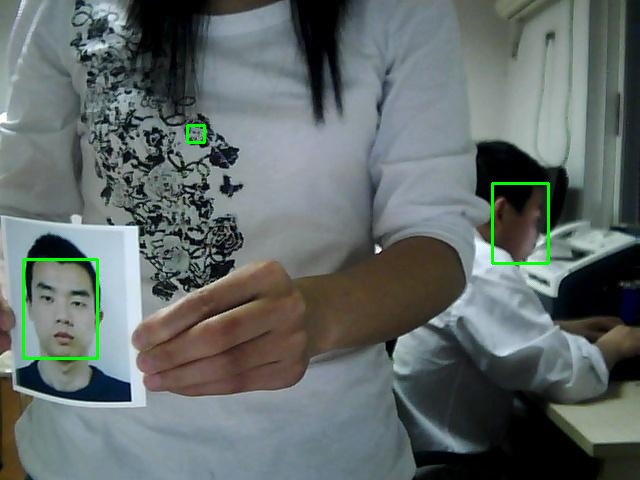

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
img = cv2.imread("/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_final_jpg/face_fake/014922.jpg")

bboxes = detector.detect(img)

print("num face:", len(bboxes))

for box in bboxes:
    x1,y1,x2,y2 = box.astype(int)
    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

cv2_imshow(img)